## Árvores de regressão - exercícios 02

Este exercício será uma continuação do anterior, mesma base, mesmas variáveis - vamos tentar buscar a 'melhor árvore'.


*Atenção - Utilizar a base de dados em anexo que é a mesma base que utilizamos na atividade anterior! A base Boston, assim como para a primeira atividade foi descontinuada e não deve ser utilizada*

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn import datasets
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### 1. Execute os passos do exercício anterior, até que você tenha uma árvore de regressão predizendo o valor do imóvel na base de treinamento.

In [4]:



# carregar base
df = pd.read_csv('housing.csv')

# verificar dados faltantes
print(df.isna().sum())

# remover valores ausentes
df = df.dropna()

# transformar variável categórica em numérica
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# separar X e y
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# árvore inicial
arvore = DecisionTreeRegressor(random_state=42)
arvore.fit(X_train, y_train)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


DecisionTreeRegressor(random_state=42)

### 2.  Calcule o caminho indicado pelos CCP-alfas dessa árvore.

In [5]:
path = arvore.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(ccp_alphas)

[0.00000000e+00 3.26285565e-05 3.26285565e-05 ... 7.91724881e+08
 1.65578775e+09 4.09128877e+09]


In [7]:
print(len(ccp_alphas))

13453


### 3. Paca cada valor de alpha obtido no item 2, treine uma árvore com o respectivo alfa, e guarde essa árvore em uma lista.

In [9]:
arvores = []

for alpha in ccp_alphas[::200]:
    arv = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    arv.fit(X_train, y_train)
    arvores.append(arv)

print("Quantidade de árvores:", len(arvores))

Quantidade de árvores: 68


### 4. Para cada árvore na lista, calcule o MSE da árvore.

In [11]:
mse_treino = []
mse_teste = []

for arv in arvores:
    pred_treino = arv.predict(X_train)
    pred_teste = arv.predict(X_test)
    
    mse_treino.append(mean_squared_error(y_train, pred_treino))
    mse_teste.append(mean_squared_error(y_test, pred_teste))
print("Primeiros MSE de treino:", mse_treino[:5])
print("Primeiros MSE de teste:", mse_teste[:5])

Primeiros MSE de treino: [0.0, 158.68420161547607, 1095.9938683691523, 3309.9501896081674, 6522.068435496969]
Primeiros MSE de teste: [4618248927.81973, 4618258324.069728, 4618308606.632091, 4618252522.6517515, 4618372384.485988]


### 5. Monte um gráfico do MSE pelo alpha, escolha um valor de alpha perto do ponto de mínimo do MSE

In [17]:
print(len(alphas_usados))
print(len(mse_treino))
print(len(mse_teste))

68
68
68


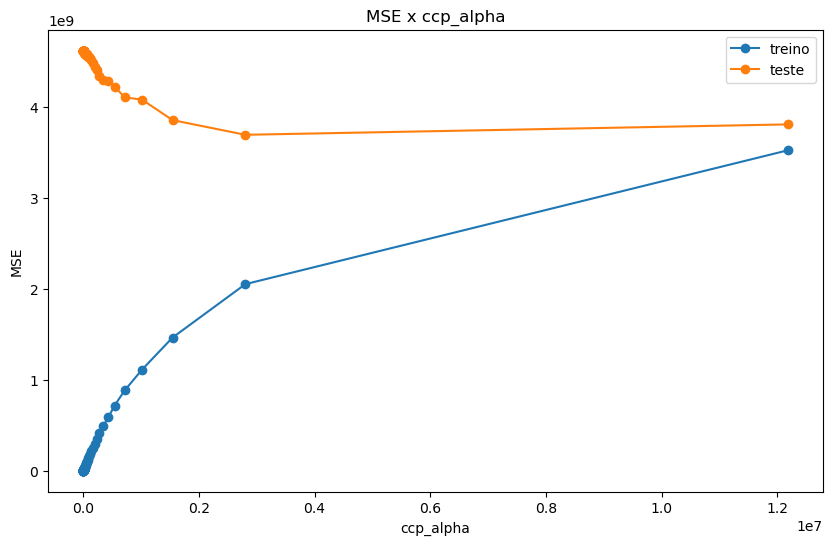

In [18]:

plt.close('all')
plt.close('all')

plt.figure(figsize=(10,6))

plt.plot(alphas_usados, mse_treino, marker='o', label='treino')
plt.plot(alphas_usados, mse_teste, marker='o', label='teste')

plt.xlabel('ccp_alpha')
plt.ylabel('MSE')
plt.title('MSE x ccp_alpha')

plt.legend()
plt.show()

In [21]:
indice_melhor = np.argmin(mse_teste)

melhor_alpha = alphas_usados[indice_melhor]

print("Melhor alpha:", melhor_alpha)

Melhor alpha: 2800590.7668121685


### 6. Calcule o R-quadrado dessa árvore encontrada no item acima

In [23]:
# treinar a árvore com o melhor alpha encontrado
arvore_final = DecisionTreeRegressor(random_state=42, ccp_alpha=melhor_alpha)

arvore_final.fit(X_train, y_train)

# fazer previsão na base de teste
pred = arvore_final.predict(X_test)

# calcular o R²
r2 = r2_score(y_test, pred)

print("R² da árvore final:", r2)

R² da árvore final: 0.7270645411800443


### 7. Visualize esta árvore.

In [ ]:
plt.close('all')

plt.figure(figsize=(20,10))

plot_tree(
    arvore_final,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()